In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def white_balance(img):
    A_SHIFT=-10
    B_SHIFT=10
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    A = A.astype(np.float32)
    B = B.astype(np.float32)
 
 
    A = A - (np.mean(A) - 128) + A_SHIFT
    B = B - (np.mean(B) - 128) + B_SHIFT
 
 
    A = np.clip(A, 0, 255).astype(np.uint8)
    B = np.clip(B, 0, 255).astype(np.uint8)
 
 
    return cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2BGR)

In [4]:
def restore_red(img):
    b, g, r = cv2.split(img)
    boost = cv2.equalizeHist(r)
    RED_STRENGTH=20
    strength = RED_STRENGTH / 100.0
    r_new = cv2.addWeighted(r, 1 - strength, boost, strength, 0)
    return cv2.merge([b, g, r_new])

In [5]:
def clahe_enhance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    CLAHE_CLIP=1.2
    clahe = cv2.createCLAHE(clipLimit=max(CLAHE_CLIP, 0.1))
    L2 = clahe.apply(L)
    return cv2.cvtColor(cv2.merge([L2, A, B]), cv2.COLOR_LAB2BGR)


In [6]:
def dehaze(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    A = np.percentile(gray, 95)
    OMEGA=0.4
    T_MIN=0.6
    t = 1 - OMEGA * (gray / A)
    t = np.clip(t, T_MIN, 1.0)
    t = cv2.merge([t, t, t])
    J = (img.astype(np.float32) - A) / t + A
    return np.clip(J, 0, 255).astype(np.uint8)

In [7]:
def sharpen(img):
    blur = cv2.GaussianBlur(img, (3, 3), 0)
    return cv2.addWeighted(img, 1.2, blur, -0.2, 0)

In [8]:
def gamma_correct(img, g=1.1):
    inv = 1.0 / g
    table = np.array([(i / 255.0) ** inv * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

In [11]:
def auto_contrast(img):
    img = img.astype(np.float32)
    min_val = np.min(img, axis=(0,1))
    max_val = np.max(img, axis=(0,1))
    scale = 255 / (max_val - min_val + 1e-6)
    result = (img - min_val) * scale
    result = np.clip(result, 0, 255)

    return result.astype(np.uint8)

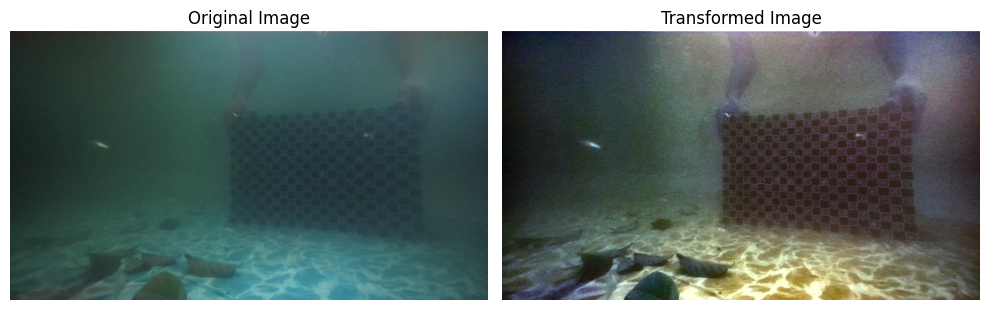

True

In [15]:
img = cv2.imread(r"C:\Users\aaish\Downloads\calib_data_front\calib_data_front\left\img_002.png")

if img is None:
    raise ValueError("Image not loaded. Check path.")

wb_img = white_balance(img)
clahe_img=clahe_enhance(wb_img)
contrast_img=auto_contrast(clahe_img)
deh_img=dehaze(contrast_img)
red_img=restore_red(deh_img)
sharp_img=sharpen(red_img)
gamma_img=gamma_correct(sharp_img)


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
wb_rgb = cv2.cvtColor(wb_img, cv2.COLOR_BGR2RGB)

cv2.imshow('transformed',gamma_img)
cv2.waitKey(0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_img)
plt.title("Transformed Image")
plt.axis('off')

plt.tight_layout()
plt.show()

output_folder = r"C:\Users\aaish\OneDrive\Desktop\new"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "img_001_processed.png")
cv2.imwrite(output_path, gamma_img)